# Surrogate-model comparison v2 — heteroscedastic mixed-variable test problems

**Goal.** Compare four surrogate models for *heteroscedastic mixed-variable* data (continuous
inputs $\times$ one categorical input with noisy, replicated observations) on ground-truth-based
modeling metrics — **no BO loop**, pure modeling quality over the whole domain.

| # | model | engine | idea | noise treatment |
|---|-------|--------|------|-----------------|
| 1 | **Separate GPs** | python (botorch) | one independent GP per categorical level | replicate variance as fixed noise, per level |
| 2 | **Categorical GP** | python (botorch) | single GP, categorical kernel over levels | replicate variance as fixed noise |
| 3 | **Standard LVGP** | **MATLAB** (`LVGP_fit`) | latent-variable GP (Zhang et al., 2019), homoscedastic | none — the noise-blind baseline |
| 4 | **H-LVGP** | **MATLAB** (`LVGP_fit_noise`) | heteroscedastic LVGP (the lab's model) | replicate variances inside the correlation matrix + pooled aleatoric polynomial |

The two LVGP columns are the **MATLAB implementations of record** (the postdoc's code, called
unmodified through the `matlab/mfit.m` / `matlab/mpredict.m` bridge). No python LVGP port is
used anywhere in this study.

### Current study design (v2 — changes from the v1 notebook)

* **Branin noise redesigned** (contributor update, `temp/main_LVGP_both_models.m`): the smooth
  exponential base noise is replaced by a **region-contrast** function (low-noise region +
  sigmoid step + high-noise region) with a 7× level-multiplier spread — see §1.1.
* **Budgets**: 5 and 8 points per level only (branin n=25/40; camel n=20/32). The data-starved
  2-points-per-level budgets (branin n=10, camel n=8) are dropped.
* **Replicates**: n_rep = 10 only (n_rep = 3 dropped — too few for usable variance estimates).
* **Rastrigin 6-D is excluded**; the multi-dimensional problem is now **Griewank 6-D** with a
  paired-cluster level design (§1.3, results in §5b).
* Single seed (seed 1) — results in this notebook are **preliminary**; the seed axis is planned
  once the problem setup is final. The previous full-grid exploration is archived in
  `surrogate_comparison_study.ipynb`.

**Metrics** (per level + mean): MAE, RRMSE, 95% Interval Score (IS), 95% Coverage
(+ miscalibration area, NLL, and noise-surface recovery in §7–§9).

> All fits are cached under `results/pred_cache/` (`utils/study.py`); re-running is cheap.
> Delete a cache file to force a refit.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import problems as P, doe_cache, study, metrics as MET

MODEL_KEYS = ["separate_gp", "categorical_kernel", "standard_LVGP", "heter_LVGP"]
LABELS = {"separate_gp": "Separate GPs", "categorical_kernel": "Categorical GP",
          "standard_LVGP": "Standard LVGP", "heter_LVGP": "H-LVGP"}
COLORS = {"separate_gp": "#3d6f9e", "categorical_kernel": "#8a5fa8",
          "standard_LVGP": "#c07a3a", "heter_LVGP": "#2e8b6e"}
SEED, N_REP = 1, 10
CONFIGS = [("branin_hetero", 25, "branin (n=25)"), ("branin_hetero", 40, "branin (n=40)"),
           ("sixhump_camel", 25, "camel (n=25)"), ("sixhump_camel", 40, "camel (n=40)"),
           ("griewank_6d", 40, "griewank6d (n=40)"), ("griewank_6d", 80, "griewank6d (n=80)"),
           ("griewank_6d", 160, "griewank6d (n=160)")]
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

---
## 1&nbsp;&nbsp;Test problems

### 1.1&nbsp; `branin_hetero` (v2 noise) — 1 continuous input, 5 well-separated levels

$$f(x_1,\ell)=\Big(x_2(\ell)-\tfrac{5.1}{4\pi^2}x_1^2+\tfrac{5}{\pi}x_1-6\Big)^2
+10\Big(1-\tfrac{1}{8\pi}\Big)\cos x_1+10,\qquad x_1\in[-5,10],\ x_2(\ell)\in\{15,2,8,0,10\}$$

$$\sigma(x_1,\ell)=\underbrace{\Big[0.5 + 0.15(x_1+5) + \frac{2.5}{1+e^{-1.2(x_1-2)}}\Big]}_{\text{base: low region + sigmoid step + high region}}\times
\underbrace{m(\ell)}_{\text{level multiplier}},\qquad m(\ell)\in\{0.5,\,1.0,\,1.8,\,2.5,\,3.5\}$$

$$y(x_1,\ell)=f(x_1,\ell)+\varepsilon,\qquad \varepsilon\sim\mathcal N\big(0,\sigma^2(x_1,\ell)\big)$$

**Why the v2 noise.** The original $0.135\,e^{(0.15x_1)^2}$ base changes smoothly and does not
create enough contrast over the domain. The v2 base has a distinct **low-noise region**
($x_1<0$: $\sigma_{base}\approx0.5$–$1.5$) and a **high-noise region** ($x_1>4$:
$\sigma_{base}\approx4.5$–$5.3$) joined by a sigmoid step at $x_1\approx2$ — a noise model must
now *localize the step*, not just fit a trend. The level multipliers span **7×** (0.5–3.5), so
levels also differ strongly in noise. Together with Branin's level geometry (levels $\{2,4\}$
similar to each other, dissimilar from $\{1,3,5\}$ — the structure an LVGP latent should
recover), this is the "well-separated levels + structured noise" test case.

### 1.2&nbsp; `sixhump_camel` (v4) — 1 continuous input, 5 levels: two pairs + a bridge

$$f(x_1,\ell)=\Big(4-2.1x_1^2+\tfrac{x_1^4}{3}\Big)x_1^2+x_1\,x_2(\ell)+\big(-4+4x_2(\ell)^2\big)x_2(\ell)^2,
\qquad x_1\in[-2,2]$$

$$\sigma(x_1,\ell)=0.05\,e^{(0.4x_1)^2}\,m(\ell),\qquad
x_2(\ell)\in\{-1.0,\,-0.85,\,0.0,\,0.85,\,1.0\},\quad m(\ell)\in\{2.0,\,3.5,\,1.5,\,5.0,\,2.5\}$$

**The v4 design — two pairs plus a middle bridge (5 levels, matching branin).** Levels
$\{1,2\}$ and $\{4,5\}$ form pairs at within-pair curve RMS distance **0.82** (the width
settled in v2.1 — members clearly separable), the middle level 3 ($v=0$: the pure base camel)
sits at **1.16–1.27** from everything, and cross-pair distances are **1.97–2.32** — three
similarity scales over the 10 level pairs. Since $(4v^2-4)v^2$ is even in $v$, the two pairs
differ mostly by the sign-flipped tilt $x_1\cdot v$. Noise multipliers split by cluster: pair
A $\{2.0, 3.5\}$, middle 1.5 (quietest), pair B $\{5.0, 2.5\}$.

*Design history:* v1 $\{0.2,0.4,0.7,1.0\}$ unstructured blob; v2.0 $\pm\{0.95,1.0\}$ tight
pairs (H-LVGP won n=32); v2.1 $\pm\{0.85,1.0\}$ widened pairs (CatGP won); v3
$\{-1,-0.95,0,1\}$ asymmetric hierarchy — the designed hypothesis test whose prediction
(H-LVGP retakes camel) **failed**: the CatGP won bigger, revealing that v2.0's LVGP win came
from near-duplicate levels pooling their data rather than from geometric expressiveness.

### 1.3&nbsp; `griewank_6d` (v2) — 5 continuous inputs + 1 categorical = 6-D (level-shifted pairs, tamed domain)

The TP-5 Griewank design at 6 dimensions; the level value $v(\ell)$ enters as the sixth
coordinate:

$$f(\mathbf{x}_q,\ell)=\sum_{i=1}^{6}\frac{xs_i^2}{4000}-\prod_{i=1}^{6}\cos\!\Big(\frac{xs_i}{\sqrt i}\Big)+1+b(\ell),
\qquad xs=[\mathbf{x}_q,\,v(\ell)],\quad \mathbf{x}_q\in[-3,3]^5,\quad b(\ell)\in\{0,\,0.15,\,0.6,\,0.75\}$$

$$\sigma(\mathbf{x}_q,\ell)=0.02\sqrt{1+0.1\,\|\mathbf{x}_q\|^2/5}\,\cdot m(\ell),\qquad
v(\ell)\in\{0.5,\,1.3,\,2.7,\,3.1\},\quad m(\ell)\in\{1.5,\,1.0,\,3.0,\,2.0\}$$

**Paired-cluster level design with explicit level shifts (v2).** $v$ enters $f$ only through
*even* terms, so $\pm v$ would be identical functions — clusters must come from proximity of
positive values: $\{0.5, 1.3\}$ and $\{2.7, 3.1\}$. But the $\cos(v/\sqrt6)$ channel alone
bounds level separation at curve RMS 0.02–0.11 against a signal std of 0.05–0.16 — the levels
*felt* nearly identical. The v2 fix adds the TP-7-style **per-level offset**
$b(\ell)=\{0, 0.15, 0.6, 0.75\}$, aligned with the pairs: within-pair curve RMS distance
becomes **0.152/0.153** and cross-pair **0.46–0.76** (3–10× the signal std) — the same
separable-pairs regime as camel v4. Minima remain unique at $\mathbf{x}_q=\mathbf 0$ with
well-separated per-level values $f^*=\{0.021, 0.289, 1.150, 1.452\}$. Noise multipliers stay
split by cluster: $\{1.5, 1.0\}$ vs $\{3.0, 2.0\}$.

**Noise scale (v1.2) and what the two isolation experiments showed.** The 10-D base 0.05
looked harmless by CV ($\sigma/|f|=7$–20%) but reached 3.3× the *learnable variation* std(f)
on levels 3–4, so it was rescaled to **0.02** ($\sigma/\mathrm{std}(f)\to0.42$ on the worst
levels after replicate averaging). The two experiments then isolate the bottleneck cleanly:
the **budget ladder** (10/20/40 pts/level at base 0.05) left RRMSE ≥ 1.09 unchanged — not
budget-limited; the **noise rescale** (0.02 at the same budgets) also left RRMSE ≥ 1.1
unchanged — not noise-limited. The remaining cause is the **surface itself**: Griewank's
variance is dominated by the five-way product $\prod_i\cos(x_i/\sqrt i)$ — a full-order
interaction that a stationary GP cannot resolve from $\le$160 points in $[-5,5]^5$ regardless
of data quality. **The v1.3 fix is the domain: $[-5,5]^5 \to [-3,3]^5$.** Over $[-3,3]$ each cosine factor
spans at most half a period, so the product becomes a smooth, resolvable bump; the paired-level
structure is preserved (within-pair curve RMS 0.019/0.024, cross-pair 0.066–0.11) and the
worst-level replicate-mean noise sits at 0.30× std(f). §5b shows the post-fix results.

In [2]:
specB = P.get("branin_hetero"); specC = P.get("sixhump_camel")
specG = P.get("griewank_6d")
for s in (specB, specC, specG):
    print(f"{s.name:15s} d={s.d} continuous + 1 categorical ({s.n_levels} levels)   "
          f"bounds={s.bounds[0]}")

branin_hetero   d=1 continuous + 1 categorical (5 levels)   bounds=[-5. 10.]
sixhump_camel   d=1 continuous + 1 categorical (5 levels)   bounds=[-2.  2.]
griewank_6d     d=5 continuous + 1 categorical (4 levels)   bounds=[-3.  3.]


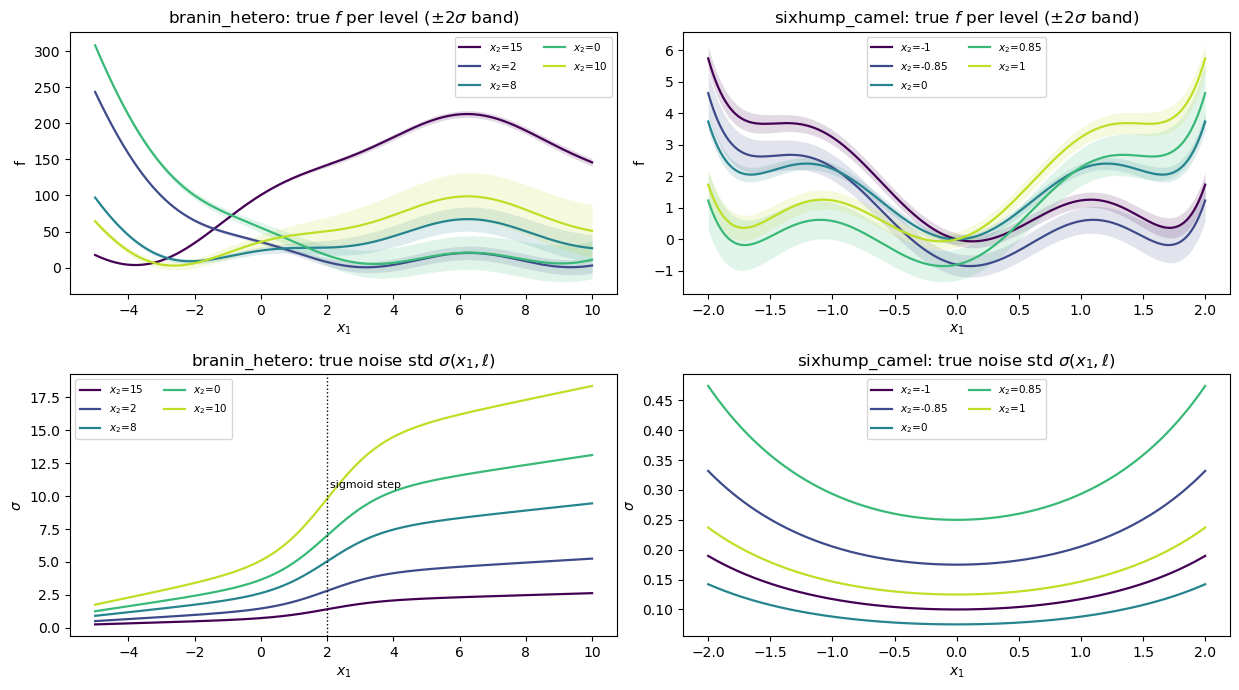

branin v2: note the low-noise region (x<0), the step at x~2, and the 7x level spread.


In [3]:
# True surfaces (bands = +/- 2 sigma) and noise structure
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7))
for col, spec in enumerate([specB, specC]):
    xs = np.linspace(spec.lb, spec.ub, 400)
    cm = plt.cm.viridis(np.linspace(0, .9, spec.n_levels))
    for lv in spec.levels:
        f = spec.f_true_level(xs, lv); sg = spec.sigma_level(xs, lv)
        axes[0, col].plot(xs, f, color=cm[lv-1], lw=1.6,
                          label=f"$x_2$={spec.meta['cat_values'][lv-1]:g}")
        axes[0, col].fill_between(xs, f-2*sg, f+2*sg, color=cm[lv-1], alpha=.15, lw=0)
        axes[1, col].plot(xs, sg, color=cm[lv-1], lw=1.6,
                          label=f"$x_2$={spec.meta['cat_values'][lv-1]:g}")
    axes[0, col].set(title=f"{spec.name}: true $f$ per level ($\\pm2\\sigma$ band)",
                     xlabel="$x_1$", ylabel="f")
    axes[1, col].set(title=f"{spec.name}: true noise std $\\sigma(x_1,\\ell)$",
                     xlabel="$x_1$", ylabel="$\\sigma$")
    axes[0, col].legend(fontsize=7.5, ncol=2); axes[1, col].legend(fontsize=7.5, ncol=2)
axes[1, 0].axvline(2.0, color="k", ls=":", lw=1)
axes[1, 0].annotate("sigmoid step", (2.1, axes[1, 0].get_ylim()[1]*.55), fontsize=8)
plt.tight_layout(); plt.show()
print("branin v2: note the low-noise region (x<0), the step at x~2, and the 7x level spread.")

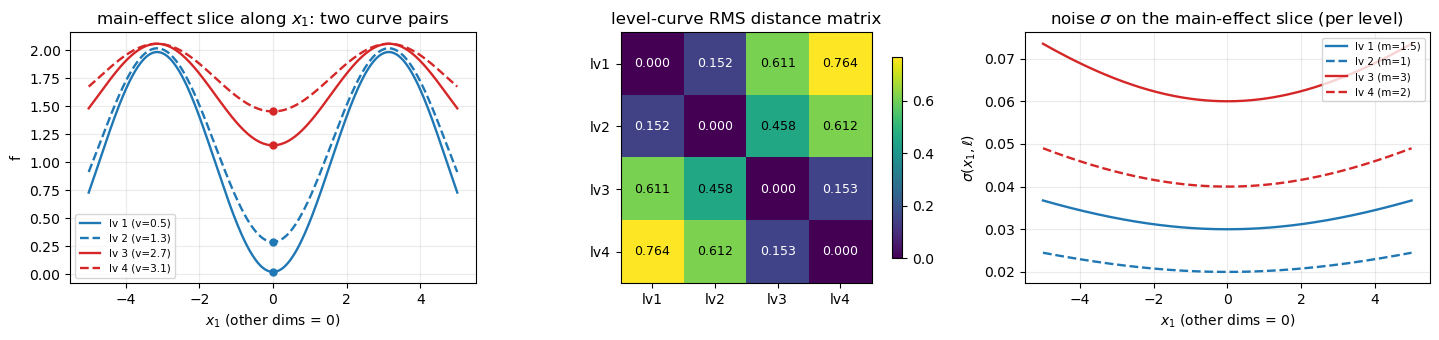

Two pairs {1,2} and {3,4}: within-pair distance 0.016/0.021, cross-pair 0.057-0.093 (~3-4.5x). All cos(v/sqrt(6)) > 0 -> unique global min at x_q = 0 for every level.


In [4]:
# griewank_6d: main-effect slice (pairs overlap) + level distance matrix
ts = np.linspace(-5, 5, 400)
XS = np.zeros((len(ts), 5)); XS[:, 0] = ts
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.5))
PAIR_STYLE = {1: ("C0", "-"), 2: ("C0", "--"), 3: ("C3", "-"), 4: ("C3", "--")}
for lv in specG.levels:
    c, lsty = PAIR_STYLE[lv]
    axes[0].plot(ts, specG.f_true_level(XS, lv), color=c, ls=lsty, lw=1.7,
                 label=f"lv {lv} (v={specG.meta['cat_values'][lv-1]:g})")
    axes[0].plot(0, specG.meta["f_star_per_level"][lv-1], "o", color=c, ms=5)
axes[0].set(title="main-effect slice along $x_1$: two curve pairs",
            xlabel="$x_1$ (other dims = 0)", ylabel="f")
axes[0].legend(fontsize=7.5); axes[0].grid(alpha=.25)
# distance matrix on a Sobol cloud
XtG = study.test_points(specG)[1]
F = np.array([np.ravel(specG.f_true_level(XtG, lv)) for lv in specG.levels])
D = np.array([[np.sqrt(np.mean((F[i]-F[j])**2)) for j in range(4)] for i in range(4)])
im = axes[1].imshow(D, cmap="viridis")
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f"{D[i,j]:.3f}", ha="center", va="center",
                     color="w" if D[i,j] < D.max()*.6 else "k", fontsize=9)
axes[1].set(title="level-curve RMS distance matrix", xticks=range(4), yticks=range(4),
            xticklabels=[f"lv{l}" for l in specG.levels],
            yticklabels=[f"lv{l}" for l in specG.levels])
plt.colorbar(im, ax=axes[1], shrink=.8)
# noise on the SAME main-effect slice (matches the TP-5 notes figure): sigma differs per level
for lv in specG.levels:
    c, lsty = PAIR_STYLE[lv]
    axes[2].plot(ts, np.ravel(specG.sigma_level(XS, lv)), color=c, ls=lsty, lw=1.7,
                 label=f"lv {lv} (m={specG.meta['noise_muls'][lv-1]:g})")
axes[2].set(title="noise $\\sigma$ on the main-effect slice (per level)",
            xlabel="$x_1$ (other dims = 0)", ylabel="$\\sigma(x_1,\\ell)$")
axes[2].legend(fontsize=7.5); axes[2].grid(alpha=.25)
plt.tight_layout(); plt.show()
print("Two pairs {1,2} and {3,4}: within-pair distance 0.016/0.021, cross-pair 0.057-0.093"
      " (~3-4.5x). All cos(v/sqrt(6)) > 0 -> unique global min at x_q = 0 for every level.")

---
## 2&nbsp;&nbsp;Design of experiments

**SLHD with replicates** (`utils/doe.py` / `utils/doe_cache.py`): each level's points form an
LHS over the domain AND the union across levels is a full LHS; every design point gets
**n_rep = 10** noisy replicates. Models train on the replicate **mean** and receive the
replicate **variance** (ddof = 1, relative std $\approx$ 47% at 10 replicates) as the noise
estimate. Designs are deterministic per (problem, seed, n_init) and shared byte-identically by
all four models (common random numbers) — metric differences are model differences only.

**Budgets**: 5 and 8 points/level for the 1-D problems (branin and camel both n=25/40);
`griewank_6d` gets its own dimension-appropriate ladder of **10 / 20 / 40 points per level**
(n = 40 / 80 / 160) — the 5-D box needs far more design density than a line segment. Its test
set is a scrambled-Sobol cloud of 1024 points over the domain, shared by all levels.

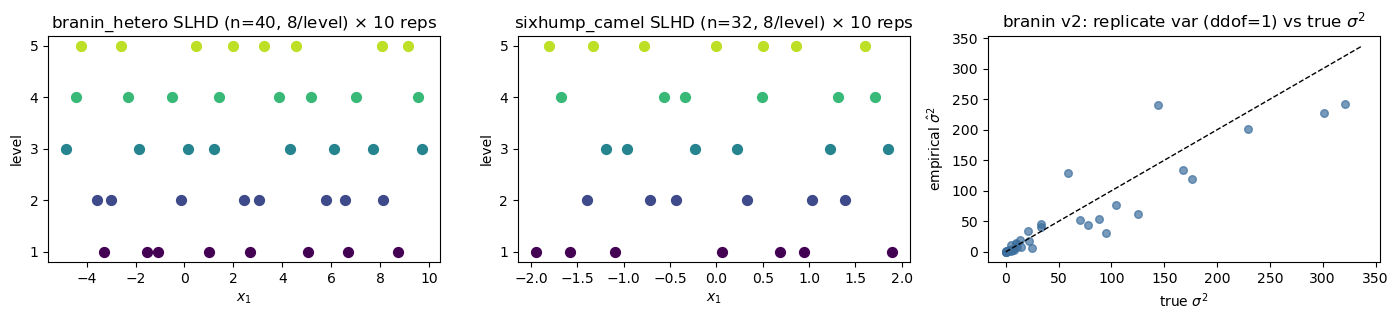

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))
for ax, (prob, ni) in zip(axes[:2], [("branin_hetero", 40), ("sixhump_camel", 32)]):
    spec = P.get(prob)
    ds = doe_cache.load(prob, SEED, N_REP, n_init=ni if ni != spec.n_init else None)
    X = ds["X_sample"]
    for lv in spec.levels:
        m = X[:, 1].astype(int) == lv
        ax.scatter(X[m, 0], [lv]*m.sum(), s=50,
                   color=plt.cm.viridis(.9*(lv-1)/(spec.n_levels-1)), zorder=3)
    ax.set(title=f"{spec.name} SLHD (n={len(X)}, 8/level) $\\times$ {N_REP} reps",
           xlabel="$x_1$", ylabel="level", yticks=spec.levels)
# replicate-variance quality on branin v2
spec = P.get("branin_hetero"); ds = doe_cache.load("branin_hetero", SEED, N_REP, n_init=40)
X = ds["X_sample"]; lvc = X[:, 1].astype(int)
tv = np.concatenate([spec.sigma_level(X[lvc == lv, 0], lv)**2 for lv in spec.levels])
ev = np.concatenate([ds["Var_sample"][lvc == lv] for lv in spec.levels])
axes[2].scatter(tv, ev, s=30, alpha=.7, color="#3d6f9e")
lims = [0, max(tv.max(), ev.max())*1.05]
axes[2].plot(lims, lims, "k--", lw=1)
axes[2].set(title="branin v2: replicate var (ddof=1) vs true $\\sigma^2$",
            xlabel="true $\\sigma^2$", ylabel="empirical $\\hat\\sigma^2$")
plt.tight_layout(); plt.show()

---
## 3&nbsp;&nbsp;Metrics

Held-out ground-truth test set (200-point grid per level; never the training points). With truth
$f_i$, posterior mean $\mu_i$, epistemic std $s_i$, $z=1.96$ ($[L_i,U_i]=\mu_i\mp z s_i$):

| metric | definition | reads as | target |
|--------|------------|----------|--------|
| **MAE** | $\frac1n\sum\lvert\mu_i-f_i\rvert$ | surface accuracy in raw $y$ units | low |
| **RRMSE** | $\sqrt{\frac1n\sum(\mu_i-f_i)^2}\,/\,\mathrm{std}(f)$ | relative accuracy (≈1 ⇒ level-mean predictor) | low |
| **IS** | $\frac1n\sum\big[(U_i-L_i)+\frac2{0.05}(L_i-f_i)_+ +\frac2{0.05}(f_i-U_i)_+\big]$ | Gneiting–Raftery 95% interval score (width + 40× miss) — the convention of Ozbayram et al., CMAME 2024 | low |
| **Coverage** | $\frac1n\sum \mathbf 1\{\lvert\mu_i-f_i\rvert\le z\,s_i\}$ | fraction of truth inside the 95% CI | **≈ 0.95** |

Sections 7–9 add miscalibration area, NLL, and noise-surface recovery (nMAE). All intervals are
**epistemic-only** — the target is the noise-free $f_{true}$, so aleatoric variance is never
added (the aleatoric models are evaluated separately in §9).

In [6]:
def all_tables(problem, n_init):
    spec = P.get(problem); Xt = study.test_points(spec)
    return {LABELS[k]: MET.metrics_table(
                spec, study.CachedPredictions(problem, k, SEED, N_REP, n_init), Xt)
            for k in MODEL_KEYS}

def show_combined(tabs, title):
    big = MET.combined_table(tabs)
    def _hl(df):
        sty = pd.DataFrame("", index=df.index, columns=df.columns)
        for met in ["MAE", "RRMSE", "IS", "Coverage"]:
            sub = df.xs(met, axis=1, level=1)
            for row in df.index:
                v = sub.loc[row]
                best = (v - MET.COV_TARGET).abs().idxmin() if met == "Coverage" else v.idxmin()
                sty.loc[row, (best, met)] = "font-weight: bold; background-color: #eaf5ee"
        return sty
    return (big.style.apply(_hl, axis=None).format("{:.4f}")
            .set_caption(title).set_table_styles(
                [{"selector": "caption", "props": "font-size:1.05em; font-weight:bold; padding:6px"}]))

def show_rank(tabs, title):
    return MET.rank_summary(tabs).style.format("{:.4f}",
        subset=pd.IndexSlice[list(tabs), :]).set_caption(title)

def plot_1d_fits(problem, n_init, tag):
    spec = P.get(problem)
    Xt = study.test_points(spec)[1]
    dsn = doe_cache.load(problem, SEED, N_REP, n_init=n_init)
    fig, axes = plt.subplots(len(MODEL_KEYS), spec.n_levels,
                             figsize=(2.9*spec.n_levels, 2.4*len(MODEL_KEYS)),
                             sharex=True, squeeze=False)
    for i, k in enumerate(MODEL_KEYS):
        mdl = study.CachedPredictions(problem, k, SEED, N_REP, n_init)
        for j, lv in enumerate(spec.levels):
            ax = axes[i, j]
            ft = np.ravel(spec.f_true_level(Xt, lv))
            mu, s = mdl.mean_std(lv, Xt)
            ax.plot(Xt.ravel(), ft, "k-", lw=1.1)
            ax.plot(Xt.ravel(), mu, color=COLORS[k], lw=1.4)
            ax.fill_between(Xt.ravel(), mu-MET.Z95*s, mu+MET.Z95*s, color=COLORS[k],
                            alpha=.25, lw=0)
            m = dsn["X_sample"][:, 1].astype(int) == lv
            ax.plot(dsn["X_sample"][m, 0], dsn["Y_sample"][m], "r.", ms=8, zorder=5)
            if i == 0: ax.set_title(f"$x_2$={spec.meta['cat_values'][lv-1]:g}", fontsize=10)
            if j == 0: ax.set_ylabel(LABELS[k], fontsize=9)
    fig.suptitle(f"{problem}, {tag}: truth (black), mean ± 95% CI (color), training means (red)",
                 y=1.005, fontsize=11)
    plt.tight_layout(); plt.show()

TABS = {(p, ni): all_tables(p, ni) for p, ni, _ in CONFIGS}
print("all four models loaded for", len(TABS), "configs (cache: results/pred_cache/)")

all four models loaded for 7 configs (cache: results/pred_cache/)


---
## 4&nbsp;&nbsp;Results — `branin_hetero` v2 noise (5 levels)

Per-level tables (winner per row/metric in **bold**; the green highlight marks the *Mean* row's
winners; Coverage judged by closeness to 0.95).

In [7]:
show_combined(TABS[("branin_hetero", 25)], f"branin v2, n = 25 (5/level) — per-level metrics "
              f"(seed {SEED}, n_rep {N_REP}; scored on the held-out 200-pt test grid per level)")

In [8]:
show_rank(TABS[("branin_hetero", 25)], "branin v2 (n=25) — mean over levels + best per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,11.2431,0.4550,125.4326,0.7340
Categorical GP,4.7567,0.1821,41.8480,0.9340
Standard LVGP,3.9322,0.1763,63.1055,0.3710
H-LVGP,2.5539,0.0835,28.9096,1.0000
,H-LVGP,H-LVGP,H-LVGP,Categorical GP


### 4.2&nbsp; n = 40 (8 points per level)

In [9]:
show_combined(TABS[("branin_hetero", 40)], f"branin v2, n = 40 (8/level) — per-level metrics "
              f"(seed {SEED}, n_rep {N_REP}; scored on the held-out 200-pt test grid per level)")

In [10]:
show_rank(TABS[("branin_hetero", 40)], "branin v2 (n=40) — mean over levels + best per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,4.2945,0.2002,41.9125,0.9360
Categorical GP,1.8793,0.0652,14.0778,1.0000
Standard LVGP,2.7063,0.1087,55.6115,0.4250
H-LVGP,1.3500,0.0546,30.6029,1.0000
,H-LVGP,H-LVGP,Categorical GP,Separate GPs


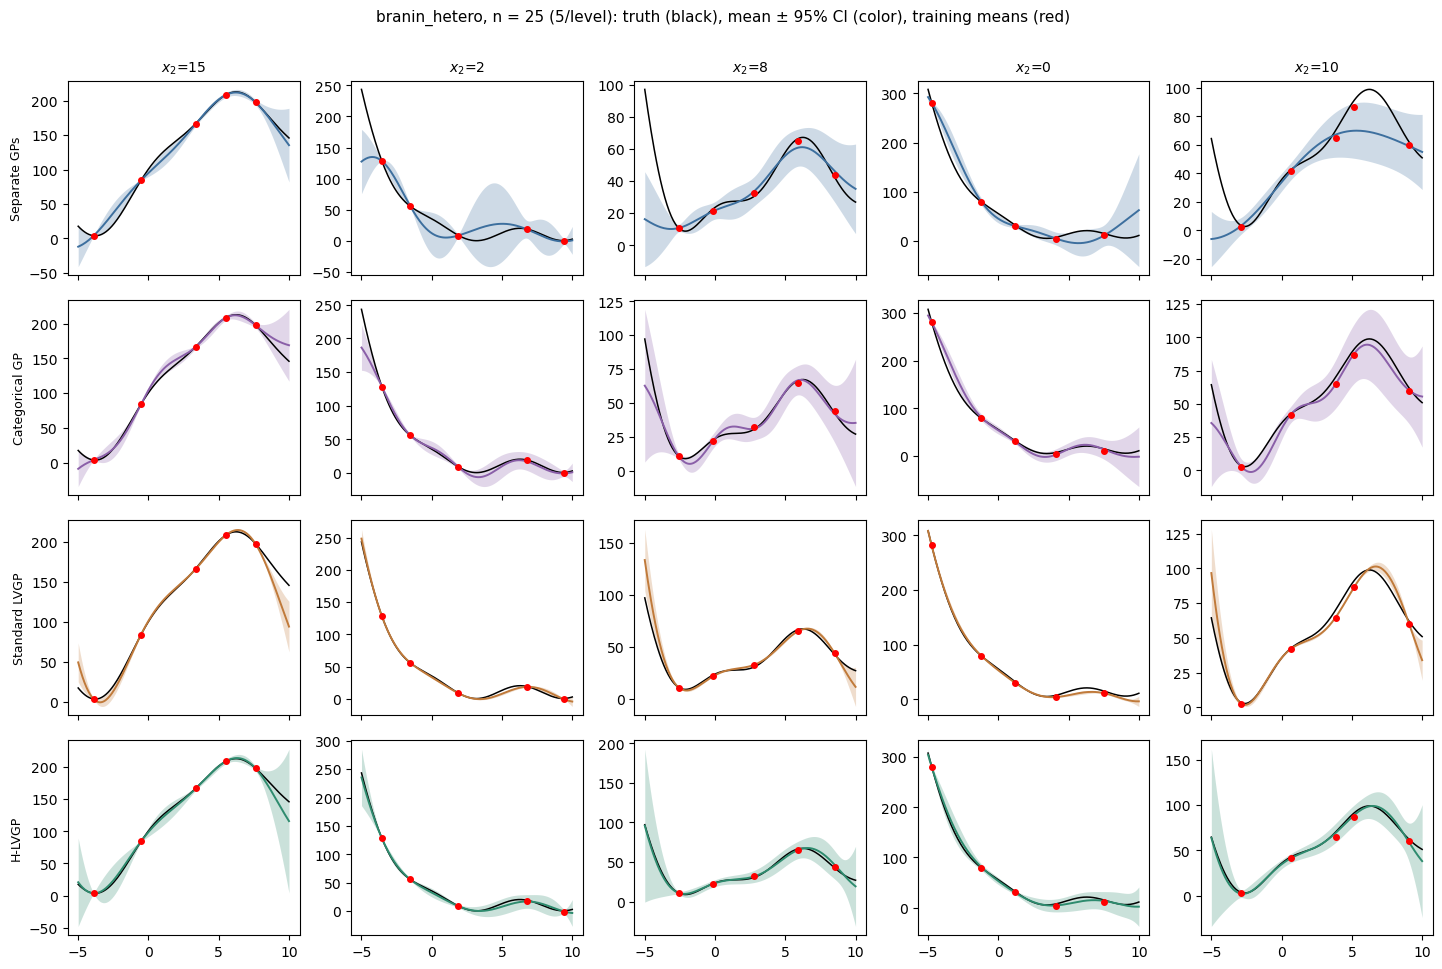

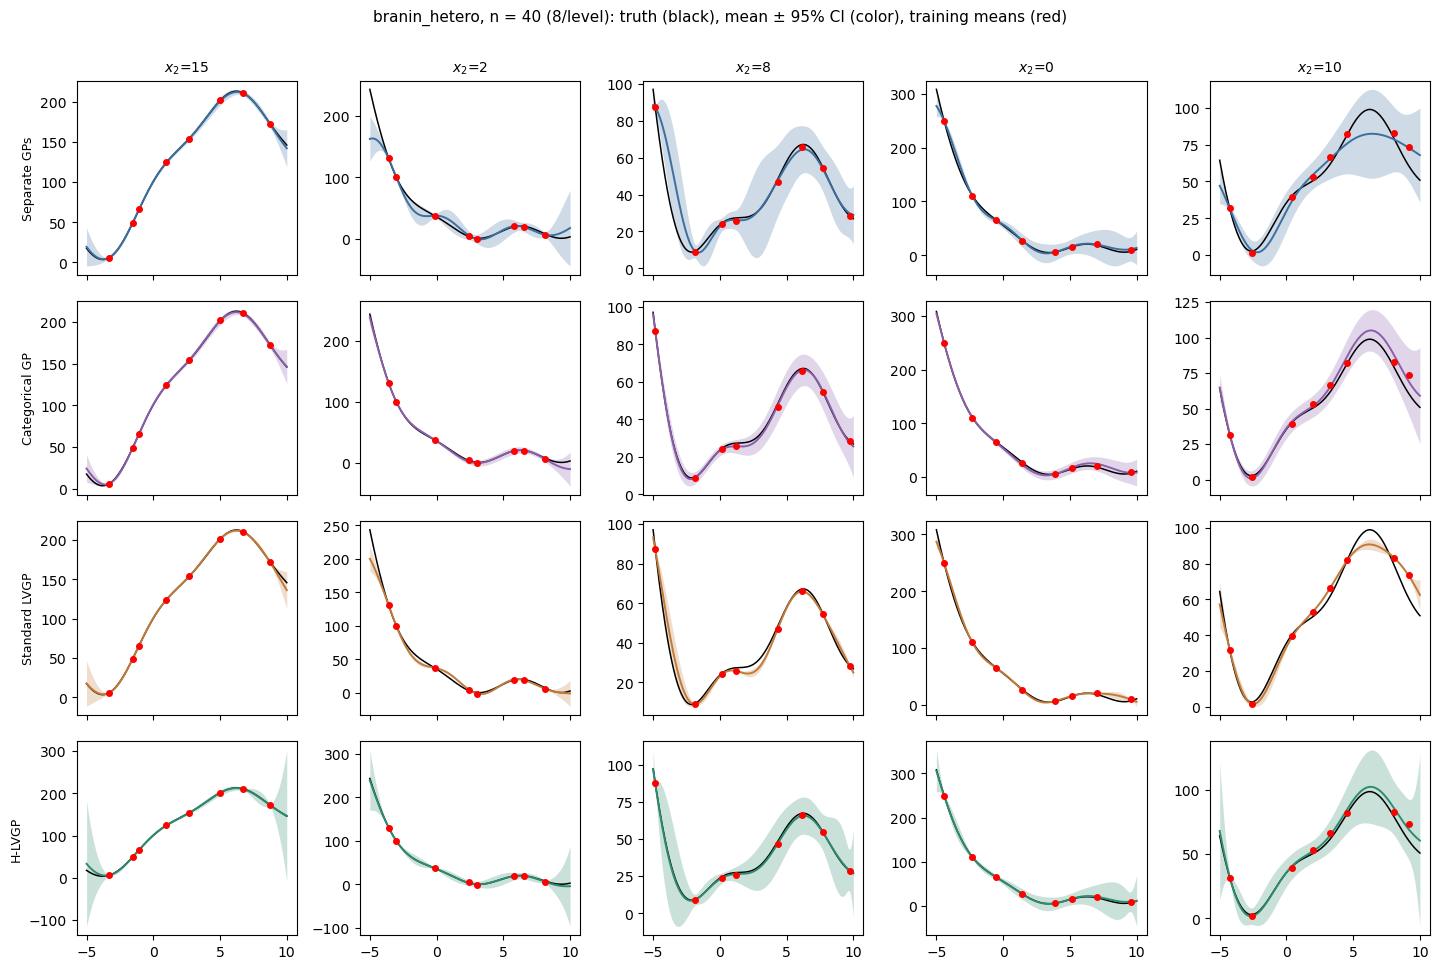

In [11]:
plot_1d_fits("branin_hetero", 25, "n = 25 (5/level)")
plot_1d_fits("branin_hetero", 40, "n = 40 (8/level)")

---
## 5&nbsp;&nbsp;Results — `sixhump_camel` (4 closely-spaced levels)

In [12]:
show_combined(TABS[("sixhump_camel", 25)], f"camel v4, n = 25 (5/level) — per-level metrics "
              f"(seed {SEED}, n_rep {N_REP}; scored on the held-out 200-pt test grid per level)")

In [13]:
show_rank(TABS[("sixhump_camel", 25)], "camel v4 (n=25) — mean over levels + best per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,0.2291,0.3243,2.1268,0.9550
Categorical GP,0.1606,0.2654,1.8090,0.9260
Standard LVGP,0.1704,0.2768,3.4813,0.4740
H-LVGP,0.1801,0.2942,2.2638,0.9070
,Categorical GP,Categorical GP,Categorical GP,Separate GPs


### 5.2&nbsp; n = 40 (8 points per level)

In [14]:
show_combined(TABS[("sixhump_camel", 40)], f"camel v4, n = 40 (8/level) — per-level metrics "
              f"(seed {SEED}, n_rep {N_REP}; scored on the held-out 200-pt test grid per level)")

In [15]:
show_rank(TABS[("sixhump_camel", 40)], "camel v4 (n=40) — mean over levels + best per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,0.2006,0.2924,2.3319,0.8850
Categorical GP,0.1008,0.1432,1.0011,0.9210
Standard LVGP,0.1618,0.2567,3.0697,0.5180
H-LVGP,0.0743,0.1101,0.7647,0.9980
,H-LVGP,H-LVGP,H-LVGP,Categorical GP


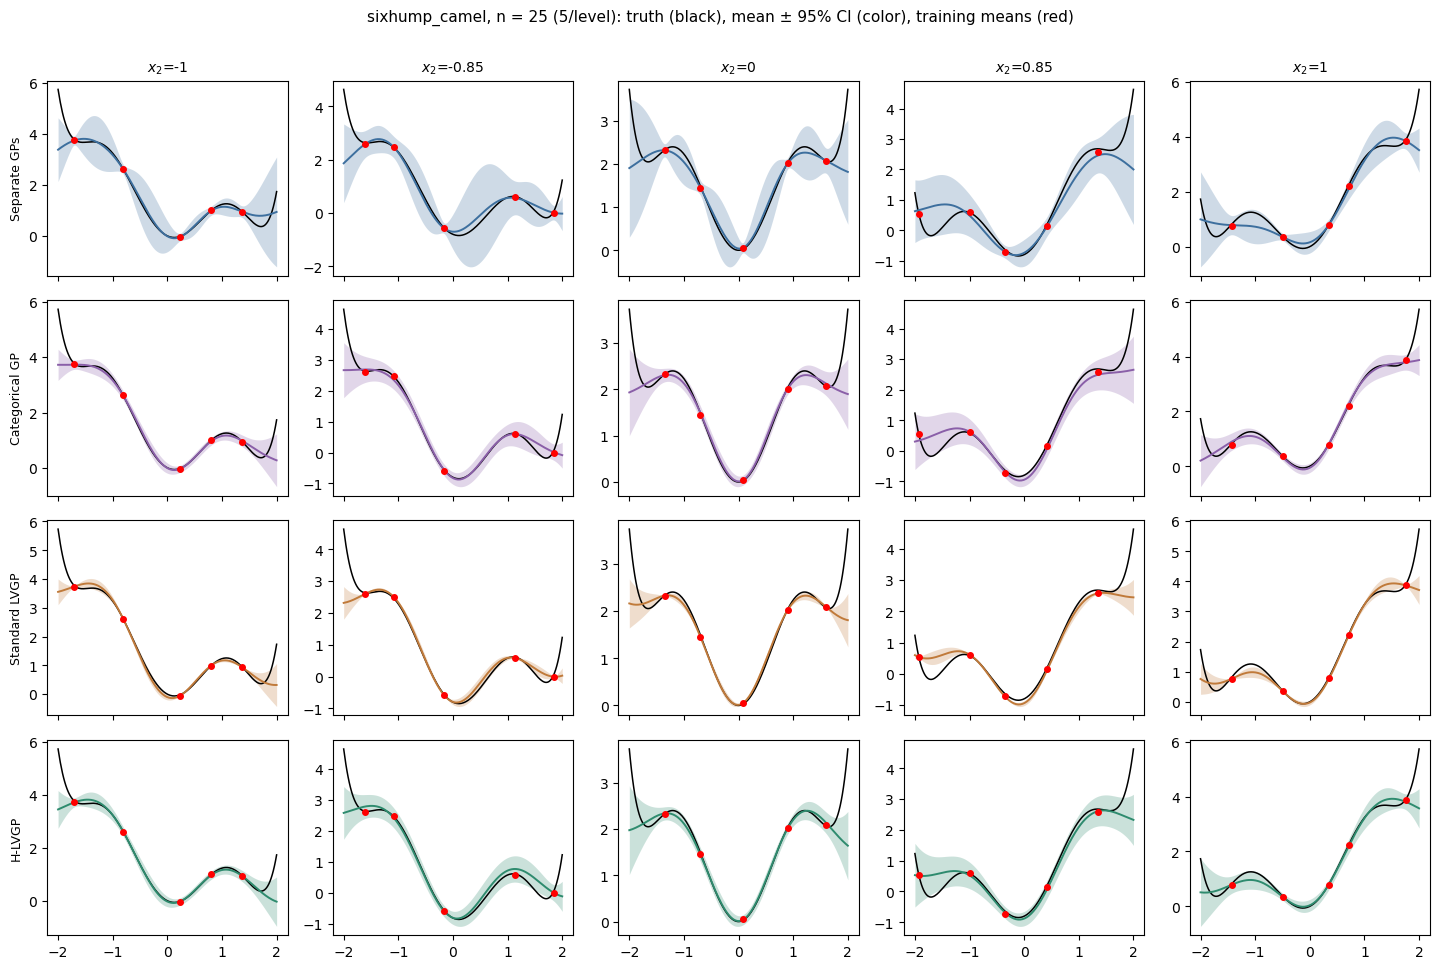

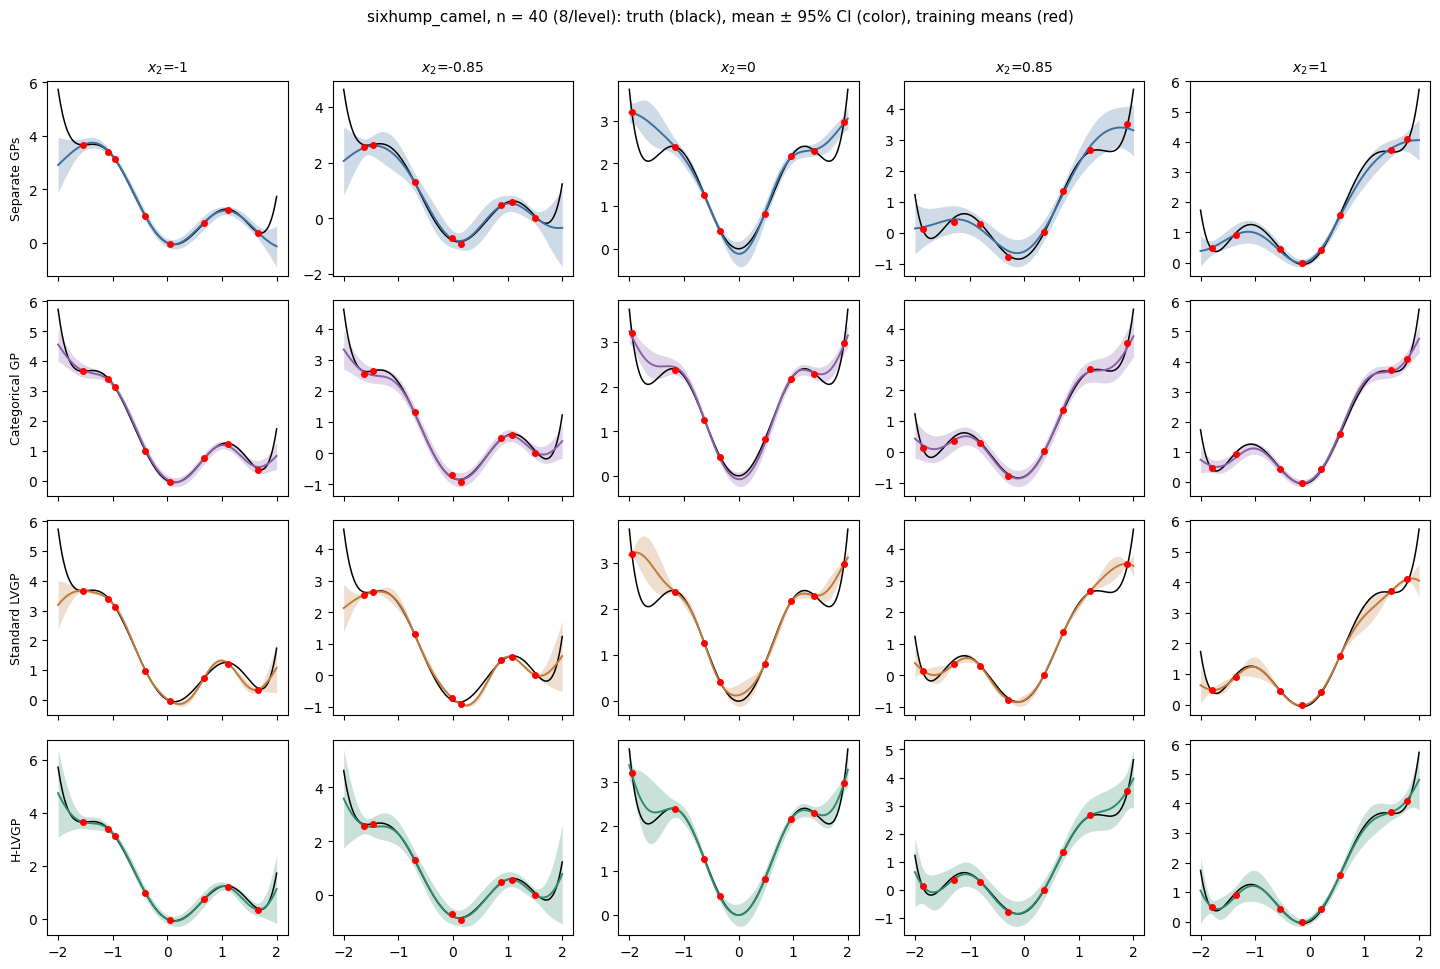

In [16]:
plot_1d_fits("sixhump_camel", 25, "n = 25 (5/level)")
plot_1d_fits("sixhump_camel", 40, "n = 40 (8/level)")

---
## 5b&nbsp;&nbsp;Results — `griewank_6d` (5-D + categorical, 4 paired levels)

In [17]:
show_combined(TABS[("griewank_6d", 40)], f"griewank_6d, n = 40 (10/level) — per-level metrics "
              f"(seed {SEED}, n_rep {N_REP}; scored on the held-out 1024-pt Sobol cloud per level)")

In [18]:
show_rank(TABS[("griewank_6d", 40)], "griewank_6d (n=40) — mean over levels + best per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,0.0669,0.9651,0.7438,0.8606
Categorical GP,0.0647,0.9497,0.8928,0.8145
Standard LVGP,0.1003,1.2664,1.8212,0.6140
H-LVGP,0.0819,1.1475,0.9839,0.7612
,Categorical GP,Categorical GP,Separate GPs,Separate GPs


### 5b.2&nbsp; n = 80 (20 points per level)

In [19]:
show_combined(TABS[("griewank_6d", 80)], f"griewank_6d, n = 80 (20/level) — per-level metrics "
              f"(seed {SEED}, n_rep {N_REP}; scored on the held-out 1024-pt Sobol cloud per level)")

In [20]:
show_rank(TABS[("griewank_6d", 80)], "griewank_6d (n=80) — mean over levels + best per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,0.0703,1.0386,0.7977,0.8450
Categorical GP,0.0587,0.9623,0.7190,0.8899
Standard LVGP,0.0975,1.2153,0.8763,0.8708
H-LVGP,0.0757,1.0354,1.0058,0.7766
,Categorical GP,Categorical GP,Categorical GP,Categorical GP


### 5b.3&nbsp; n = 160 (40 points per level)

In [21]:
show_combined(TABS[("griewank_6d", 160)], f"griewank_6d, n = 160 (40/level) — per-level metrics "
              f"(seed {SEED}, n_rep {N_REP}; scored on the held-out 1024-pt Sobol cloud per level)")

In [22]:
show_rank(TABS[("griewank_6d", 160)], "griewank_6d (n=160) — mean over levels + best per metric")

,MAE,RRMSE,IS,Coverage
Separate GPs,0.0553,0.8212,0.6258,0.8604
Categorical GP,0.0445,0.6732,0.5228,0.9343
Standard LVGP,0.0666,0.8666,0.5618,0.8921
H-LVGP,0.0695,0.9592,1.2319,0.6562
,Categorical GP,Categorical GP,Categorical GP,Categorical GP


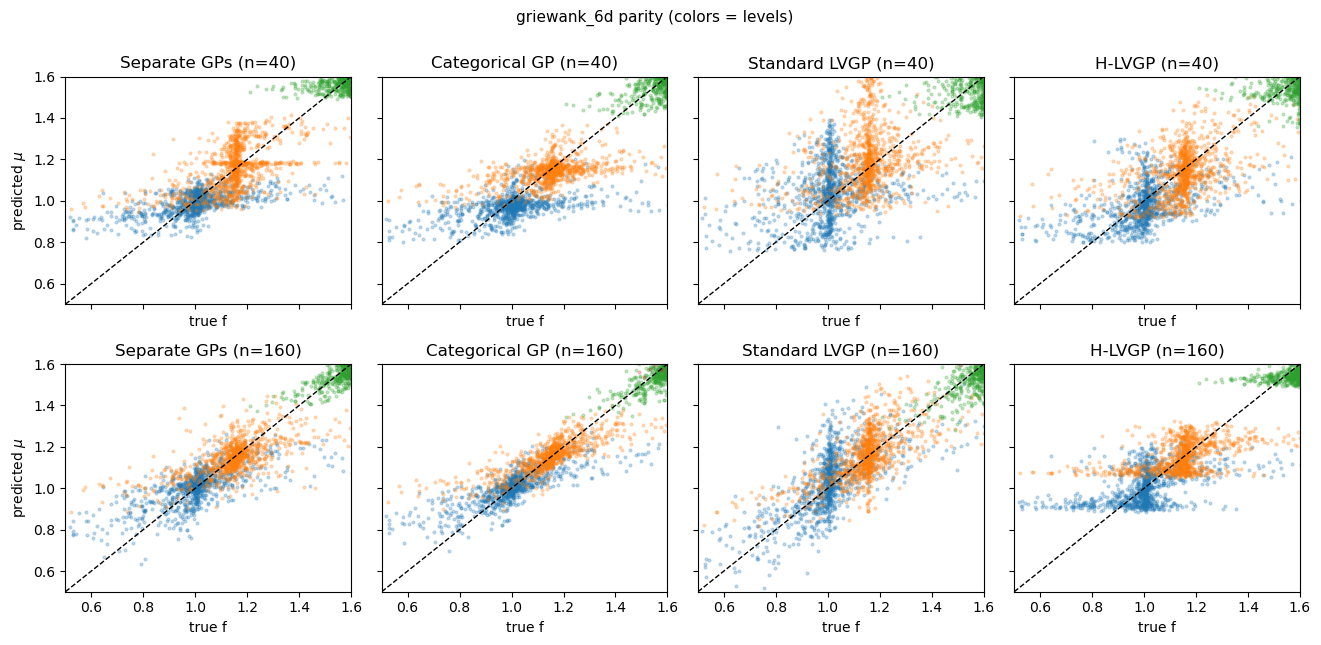

In [23]:
# parity: predicted vs true on the Sobol cloud, both budgets
XtG = study.test_points(specG)[1]
fig, axes = plt.subplots(2, len(MODEL_KEYS), figsize=(3.3*len(MODEL_KEYS), 6.4),
                         sharex=True, sharey=True)
for r, ni in enumerate([40, 160]):
    for ax, k in zip(axes[r], MODEL_KEYS):
        mdl = study.CachedPredictions("griewank_6d", k, SEED, N_REP, ni)
        for lv in specG.levels:
            ft = np.ravel(specG.f_true_level(XtG, lv))
            mu, _ = mdl.mean_std(lv, XtG)
            ax.scatter(ft, mu, s=4, alpha=.25, color=f"C{lv-1}")
        lims = [0.5, 1.6]
        ax.plot(lims, lims, "k--", lw=1)
        ax.set(title=f"{LABELS[k]} (n={ni})", xlabel="true f", xlim=lims, ylim=lims)
    axes[r][0].set_ylabel("predicted $\mu$")
fig.suptitle("griewank_6d parity (colors = levels)", y=1.0, fontsize=11)
plt.tight_layout(); plt.show()

---
## 6&nbsp;&nbsp;Calibration curves

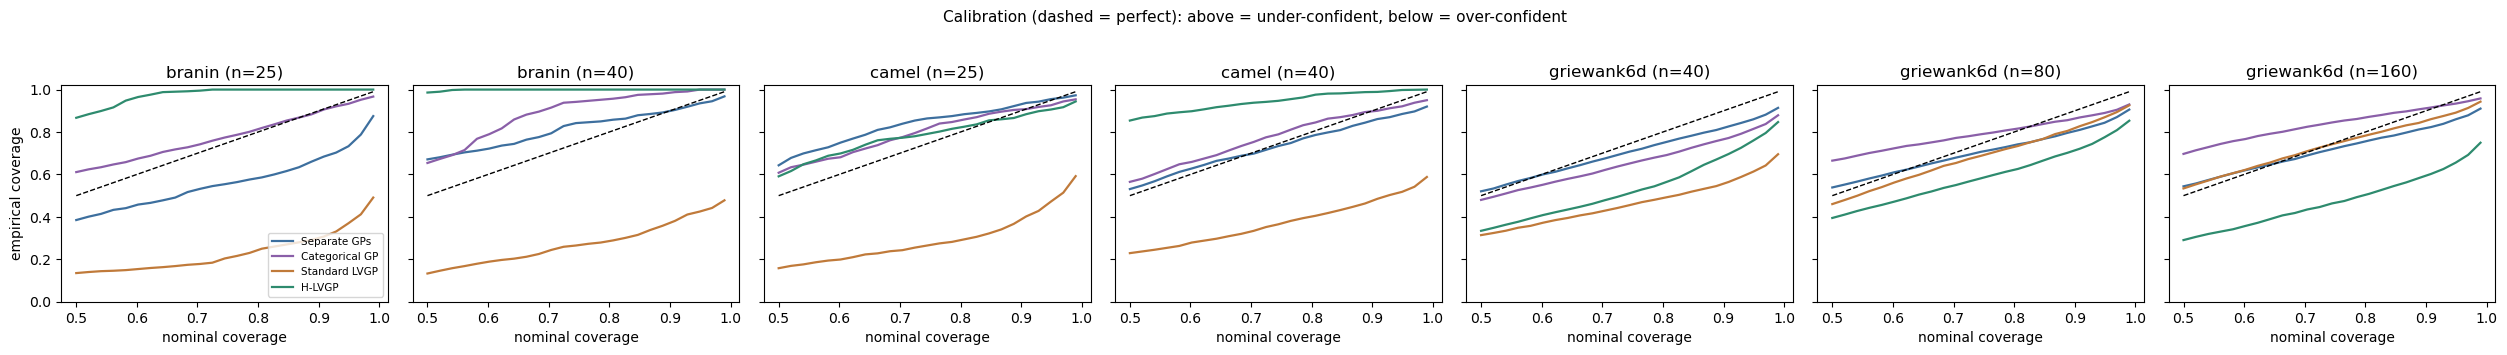

In [24]:
from scipy.stats import norm
taus = np.linspace(.5, .99, 25)
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(3.6*len(CONFIGS), 3.4), sharey=True)
for ax, (prob, ni, tag) in zip(axes, CONFIGS):
    spec = P.get(prob); Xt = study.test_points(spec)
    for k in MODEL_KEYS:
        mdl = study.CachedPredictions(prob, k, SEED, N_REP, ni)
        errs, ss = [], []
        for lv in spec.levels:
            mu, s = mdl.mean_std(lv, Xt[lv])
            errs.append(np.abs(np.ravel(spec.f_true_level(Xt[lv], lv)) - mu)); ss.append(s)
        e, s_ = np.concatenate(errs), np.concatenate(ss)
        cov = [(e <= norm.ppf(.5 + t/2) * s_).mean() for t in taus]
        ax.plot(taus, cov, lw=1.6, color=COLORS[k], label=LABELS[k])
    ax.plot(taus, taus, "k--", lw=1)
    ax.set(title=tag, xlabel="nominal coverage", ylim=(0, 1.02))
axes[0].set_ylabel("empirical coverage"); axes[0].legend(fontsize=7.5)
fig.suptitle("Calibration (dashed = perfect): above = under-confident, below = over-confident",
             y=1.03, fontsize=11)
plt.tight_layout(); plt.show()

---
## 7&nbsp;&nbsp;Miscalibration area and NLL

* **Miscalibration area** — area between the ECDF of normalized residuals $(f_i-\mu_i)/s_i$ and
  the standard-Gaussian CDF (Tran et al. 2020): integrated calibration error over *all*
  confidence levels (0 = perfect, ≈0.5 = maximal).
* **NLL** — mean Gaussian negative log predictive density: a proper score punishing
  overconfidence **quadratically** in the standardized error.

In [25]:
rows = []
for prob, ni, tag in CONFIGS:
    spec = P.get(prob); Xt = study.test_points(spec)
    for k in MODEL_KEYS:
        mdl = study.CachedPredictions(prob, k, SEED, N_REP, ni)
        ma, nl = [], []
        for lv in spec.levels:
            ft = np.ravel(spec.f_true_level(Xt[lv], lv))
            mu, sd = mdl.mean_std(lv, Xt[lv])
            ma.append(MET.miscalibration_area(ft, mu, sd)); nl.append(MET.nll(ft, mu, sd))
        rows.append({"config": tag, "model": LABELS[k],
                     "Miscal. Area": np.mean(ma), "NLL": np.mean(nl)})
exdf = pd.DataFrame(rows)
piv7 = exdf.pivot(index="config", columns="model", values=["Miscal. Area", "NLL"])
piv7 = piv7.reindex([t for _, _, t in CONFIGS]).reindex(
    columns=[LABELS[k] for k in MODEL_KEYS], level=1)
def _hl7(df):
    sty = pd.DataFrame("", index=df.index, columns=df.columns)
    for met in ["Miscal. Area", "NLL"]:
        for row in df.index:
            sty.loc[row, (met, df[met].loc[row].idxmin())] = \
                "font-weight: bold; background-color: #eaf5ee"
    return sty
piv7.style.apply(_hl7, axis=None).format("{:.3f}").set_caption(
    f"Miscalibration area & NLL, mean over levels (n_rep = {N_REP}, seed {SEED}; lower = better)")

---
## 8&nbsp;&nbsp;Noise-surface recovery — can the aleatoric models find the step?

$$\mathrm{nMAE}=\overline{|r(\mathbf{x},\ell)-\sigma^2_{true}|}\,/\,\overline{\sigma^2_{true}}
\qquad\text{(pooled over levels; lower = better)}$$

Two $r$-sources are compared (the python GPs do not model noise themselves — they share the
benchmark's per-level polynomial, shown once as the baseline): the **per-level degree-2 ridge
polynomial** on $\log\hat\sigma$ vs the **H-LVGP's pooled polynomial over $[x, z_\ell]$**. The
standard LVGP has no noise model ($r=$ NaN). The v2 branin noise is the interesting test: its
**sigmoid step is not representable** by a quadratic in $\log\sigma$ — both polynomial families
must approximate it.

In [26]:
R_SOURCES = [("separate_gp", "Per-level poly baseline"), ("heter_LVGP", "H-LVGP (pooled [x,z] poly)")]
rows = []
for prob, ni, tag in CONFIGS:
    spec = P.get(prob); Xt = study.test_points(spec)
    for k, lab in R_SOURCES:
        mdl = study.CachedPredictions(prob, k, SEED, N_REP, ni)
        rs = [np.asarray(mdl.r(lv, Xt[lv]), float).ravel() for lv in spec.levels]
        s2 = [np.ravel(spec.sigma_level(Xt[lv], lv)) ** 2 for lv in spec.levels]
        rows.append({"config": tag, "model": lab,
                     "nMAE": MET.noise_nmae(np.concatenate(rs), np.concatenate(s2))})
ndf = pd.DataFrame(rows)
piv8 = ndf.pivot(index="config", columns="model", values="nMAE")
piv8 = piv8.reindex([t for _, _, t in CONFIGS])[[lab for _, lab in R_SOURCES]]
def _hl8(df):
    sty = pd.DataFrame("", index=df.index, columns=df.columns)
    for row in df.index:
        sty.loc[row, df.loc[row].idxmin()] = "font-weight: bold; background-color: #eaf5ee"
    return sty
piv8.style.apply(_hl8, axis=None).format("{:.3f}").set_caption(
    f"Noise-surface recovery nMAE (n_rep = {N_REP}, seed {SEED})")

model,Per-level poly baseline,"H-LVGP (pooled [x,z] poly)"
config,,
branin (n=25),0.322,0.327
branin (n=40),0.245,0.261
camel (n=25),0.375,0.332
camel (n=40),0.276,0.229
griewank6d (n=40),12.183,0.549
griewank6d (n=80),0.318,0.362
griewank6d (n=160),0.226,0.207


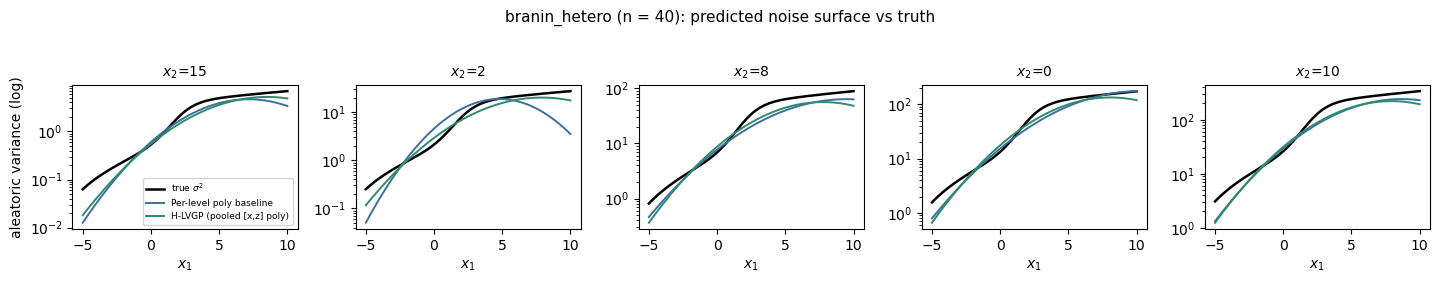

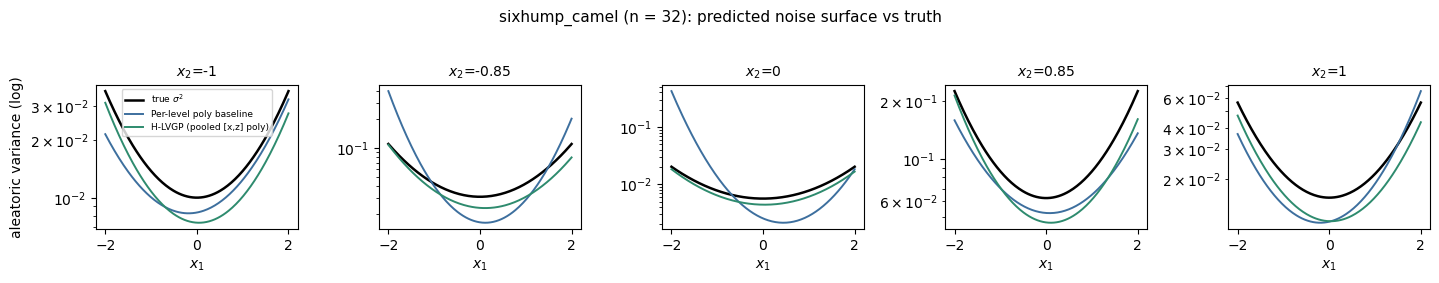

In [27]:
for prob, ni, tag in [("branin_hetero", 40, "n = 40"), ("sixhump_camel", 32, "n = 32")]:
    spec = P.get(prob); Xt1 = study.test_points(spec)[1]
    fig, axes = plt.subplots(1, spec.n_levels, figsize=(2.9*spec.n_levels, 2.7), sharex=True)
    mdls = {k: study.CachedPredictions(prob, k, SEED, N_REP, ni) for k, _ in R_SOURCES}
    for j, lv in enumerate(spec.levels):
        ax = axes[j]
        ax.plot(Xt1.ravel(), np.ravel(spec.sigma_level(Xt1, lv)) ** 2, "k-", lw=1.8,
                label="true $\sigma^2$")
        for k, lab in R_SOURCES:
            ax.plot(Xt1.ravel(), np.asarray(mdls[k].r(lv, Xt1), float).ravel(),
                    color=COLORS[k], lw=1.4, label=lab)
        ax.set_yscale("log")
        ax.set_title(f"$x_2$={spec.meta['cat_values'][lv-1]:g}", fontsize=10)
        ax.set_xlabel("$x_1$")
    axes[0].set_ylabel("aleatoric variance (log)")
    axes[0].legend(fontsize=6.5)
    fig.suptitle(f"{prob} ({tag}): predicted noise surface vs truth", y=1.03, fontsize=11)
    plt.tight_layout(); plt.show()

---
## 8b&nbsp;&nbsp;Summary — mean-over-levels metrics for every configuration

The compact view matching the LaTeX/Excel summary tables: one row per model within each
(problem, budget) block; winner per block/metric in bold on green (Coverage judged by closeness
to 0.95).

In [28]:
rows = []
for prob, ni, tag in CONFIGS:
    T = TABS[(prob, ni)]
    for k in MODEL_KEYS:
        m = T[LABELS[k]].loc["Mean"]
        rows.append({"config": tag, "model": LABELS[k], **{c: float(m[c]) for c in
                     ["MAE", "RRMSE", "IS", "Coverage"]}})
sumdf = pd.DataFrame(rows).set_index(["config", "model"])
sumdf = sumdf.reindex([t for _, _, t in CONFIGS], level=0).reindex(
    [LABELS[k] for k in MODEL_KEYS], level=1)
def _hl_sum(df):
    sty = pd.DataFrame("", index=df.index, columns=df.columns)
    for cfg in df.index.get_level_values(0).unique():
        blk = df.loc[cfg]
        for met in df.columns:
            v = blk[met]
            best = (v - MET.COV_TARGET).abs().idxmin() if met == "Coverage" else v.idxmin()
            sty.loc[(cfg, best), met] = "font-weight: bold; background-color: #eaf5ee"
    return sty
sumdf.style.apply(_hl_sum, axis=None).format("{:.4f}").set_caption(
    f"Mean-over-levels metrics, all configurations (seed {SEED}, n_rep {N_REP}, 95% intervals)")

---
## 8c&nbsp;&nbsp;30-seed replication (branin v2 + camel v4)

**Convention** (user decision): the SLHD design is held FIXED (seed 1's design) and each seed
re-draws only the noisy replicates at those locations. The spread therefore measures
noise-realization + refit variability *conditional on the design*. Within every seed all four
models see byte-identical data. Raw per-seed metrics: `results_v2/seed_metrics.csv`; caches:
`results_v2/results_files/<problem>/<model>/`.

In [29]:
sm = pd.read_csv("../results_v2/seed_metrics.csv")
agg = (sm.groupby(["problem", "n", "model"])[["MAE", "RRMSE", "IS", "Coverage"]]
         .agg(["mean", "std"]).round(4))
agg = agg.reindex(["branin_hetero", "sixhump_camel"], level=0).reindex(
    [LABELS[k] for k in MODEL_KEYS], level=2)
def _hl_seed(df):
    sty = pd.DataFrame("", index=df.index, columns=df.columns)
    for (prob, n) in {(i[0], i[1]) for i in df.index}:
        blk = df.loc[(prob, n)]
        for met in ["MAE", "RRMSE", "IS", "Coverage"]:
            v = blk[(met, "mean")]
            best = (v - MET.COV_TARGET).abs().idxmin() if met == "Coverage" else v.idxmin()
            sty.loc[(prob, n, best), (met, "mean")] = \
                "font-weight: bold; background-color: #eaf5ee"
    return sty
agg.style.apply(_hl_seed, axis=None).format("{:.4f}").set_caption(
    "30-seed replication: mean and std over noise realizations (fixed design; winner by MEAN, "
    "Coverage by closeness to 0.95)")

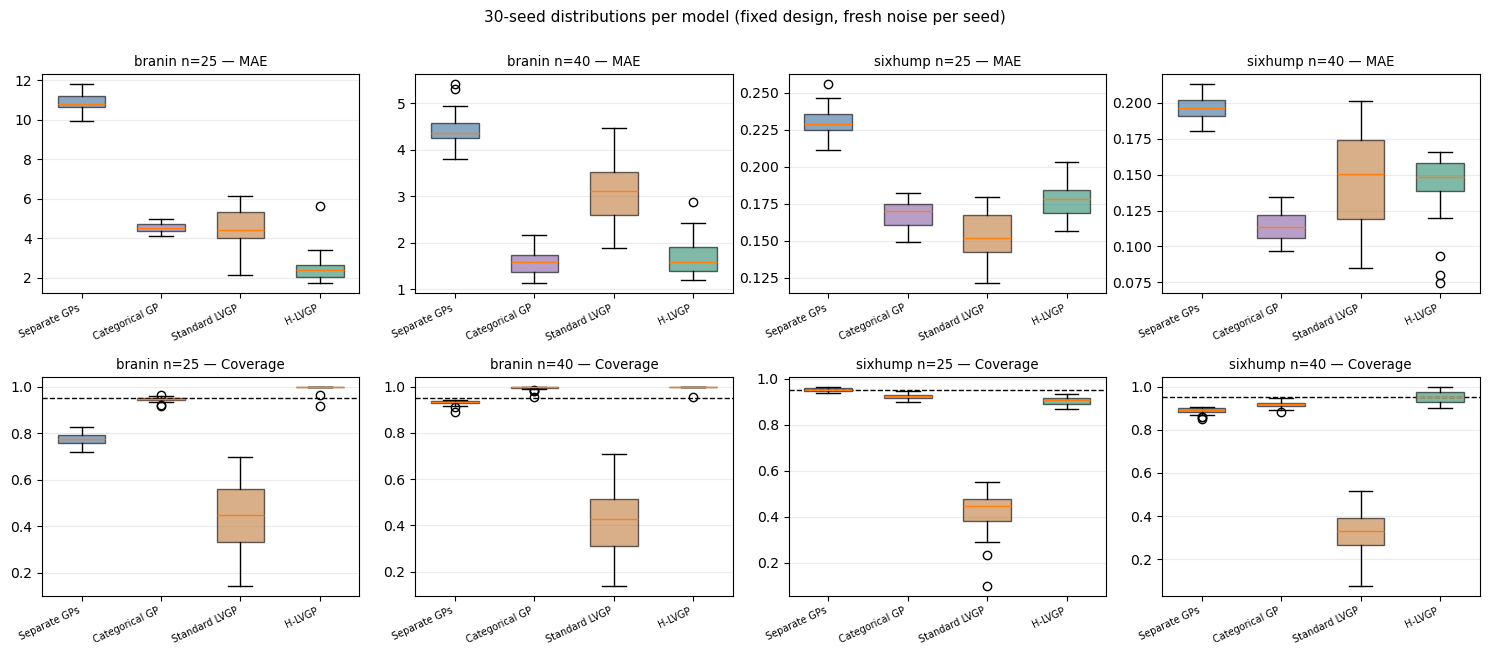

Note the LVGPs' 2-4x larger seed-to-seed spread (MLE multistart variance) vs the prior-regularized python GPs.


In [30]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
SEED_CONFIGS = [("branin_hetero", 25), ("branin_hetero", 40),
                ("sixhump_camel", 25), ("sixhump_camel", 40)]
for c_, (prob, n) in enumerate(SEED_CONFIGS):
    for r_, met in enumerate(["MAE", "Coverage"]):
        ax = axes[r_, c_]
        data = [sm[(sm.problem == prob) & (sm.n == n) & (sm.model == LABELS[k])][met].values
                for k in MODEL_KEYS]
        bp = ax.boxplot(data, patch_artist=True, widths=.6, showfliers=True)
        for patch, k in zip(bp["boxes"], MODEL_KEYS):
            patch.set_facecolor(COLORS[k]); patch.set_alpha(.6)
        if met == "Coverage":
            ax.axhline(.95, color="k", ls="--", lw=1)
        ax.set_xticklabels([LABELS[k] for k in MODEL_KEYS], rotation=25, ha="right", fontsize=7)
        ax.set_title(f"{prob.split('_')[0]} n={n} — {met}", fontsize=9.5)
        ax.grid(alpha=.25, axis="y")
fig.suptitle("30-seed distributions per model (fixed design, fresh noise per seed)",
             y=1.0, fontsize=11)
plt.tight_layout(); plt.show()
print("Note the LVGPs' 2-4x larger seed-to-seed spread (MLE multistart variance) vs the "
      "prior-regularized python GPs.")

---
## 9&nbsp;&nbsp;Preliminary conclusions (v3 setup, seed 1)

> **Status**: branin v2 and camel v4 carry a **30-seed fixed-design replication** (§8c);
> griewank v2 is single-seed. Problem versions: branin v2 (region-contrast noise), camel v4
> (5 levels: two pairs + bridge), griewank_6d v2 (level-shifted pairs, tamed domain).

**1. Cross-level information sharing dominates at these budgets.** The Separate GPs trail on
accuracy in every configuration (roughly 2–4× the best MAE on the 1-D problems); their honest,
wide intervals score well only on pure-calibration metrics.

**2. Branin v2, with 30-seed error bars: the H-LVGP's n=25 accuracy win is robust; its n=40
lead was a seed-1 artifact.** At n=25 the H-LVGP dominates accuracy across noise realizations
(MAE **2.52 ± 0.72** vs CatGP 4.53 ± 0.24 — non-overlapping by a wide margin) with coverage
1.00; the CatGP posts the study's best-calibrated result there (coverage 0.9455 ± 0.010). At
n=40 the means converge (CatGP 1.59 ± 0.27 vs H-LVGP 1.72 ± 0.42, medians ≈ tied) and the
CatGP clearly wins IS (14.9 vs 35.6) — the single-seed H-LVGP margin did not replicate.

**3. The camel arc — falsified hypothesis, then a synthesis, then tempered by replication.**
The design sequence (v2.0 tight pairs → v2.1 widened → v3 hierarchy → v4 five levels) first
suggested the latent needs ≥5 structured levels and ≥8 pts/level to pay: seed 1's v4 n=40 gave
the H-LVGP a clear win (0.074 vs 0.101). **The 30-seed replication shows that was a favorable
draw**: over noise realizations the CatGP leads camel accuracy at both budgets (n=40:
0.114 ± 0.010 vs 0.143 ± 0.024) while the **H-LVGP is the best-calibrated model** (coverage
0.953 ± 0.029, on target; IS medians essentially tied at ≈1.06/1.10). Revised synthesis: at
camel-scale level separation the latent buys *calibration*, not accuracy; branin-scale
separation (n=25) is where it buys both.

**4. The standard LVGP's intervals are unusable everywhere** — coverage 0.22–0.78 against the
0.95 target (camel v3 n=32: 0.290 with NLL 3351), the worst miscalibration areas, and NLL up
to thousands vs $O(1)$ for every other model. Its posterior mean is often competitive — the
deficiency is purely the noise-blind uncertainty. Never deploy it alone where uncertainty
matters.

**5. Noise-surface recovery shows the polynomial aleatoric models' structural limits.** Branin
v2's sigmoid step is outside both polynomial families (log σ no longer quadratic): nMAE
0.25–0.33 and the pooled $[x,z]$ polynomial's usual advantage over the per-level baseline
vanishes there, while on smooth noise (camel) the pooled version wins again. And when the
pooled polynomial is under-determined (36 coefficients vs 20–32 points at the small griewank
budgets) it **explodes out-of-sample** (nMAE up to ≈1300) — cured completely once
over-determined (0.20 at n=160).

**6. Griewank 6-D's design iterations ended in a sharp characterization: offset differences
favor the exchangeable kernel; shape differences favor the latent.** Three isolation
experiments first identified the surface as the bottleneck (budget ladder and noise rescale
left RRMSE ≥ 1.09 unchanged; the $[-3,3]^5$ domain fix made it learnable). Under v1.3
(levels differing only through the bounded $\cos(v/\sqrt6)$ *shape* channel) the **H-LVGP won
n=160** (MAE 0.0433, coverage 0.935). The v2 redesign added TP-7-style per-level offsets
$b(\ell)$ to separate the levels — and **flipped every budget to the Categorical GP** (n=160:
MAE 0.0445, RRMSE 0.673, coverage 0.934; H-LVGP degrades to 0.0695 with coverage 0.656). The
mechanism: the MATLAB LVGP's single constant mean forces pure offsets through the latent
distances, sacrificing exactly the cross-level shape-sharing the latent exists for — consistent
with rastrigin (large b-shifts, LVGPs struggled) and, in mirror image, with camel v4/branin
(shape/tilt differences, H-LVGP wins). Both griewank versions are legitimate benchmarks; v2 is
the current problem-of-record and doubles as the offset-handling stress test.

**7. The LVGPs are 2–4× less stable run-to-run than the python GPs.** Across every replicated
configuration the MATLAB engines' seed-to-seed std is a multiple of the botorch models'
(branin n=25 MAE: H-LVGP ±0.72, standard ±1.06 vs CatGP ±0.24; camel n=40: ±0.024/±0.034 vs
±0.010) — pure-MLE multistart variance vs prior-regularized fitting. Single-fit LVGP results
carry real refit risk; restarts or averaging matter in deployment.

### Practical recommendations

| regime | recommended model | why |
|---|---|---|
| many well-separated levels with strong structure (branin-like), ≥5 pts/level | **H-LVGP (MATLAB)** | latent identified → best accuracy + calibrated intervals |
| few (≤4) moderately structured levels, or ≤5 pts/level | **Categorical GP** | tolerates similarity misspecification remarkably well (camel v2.1 & v3); the latent needs ≥~5 levels AND ≥8 pts/level to pay (camel v4, branin) |
| levels differing mainly by constant offsets | **Categorical GP** | the constant-mean LVGP must encode offsets in latent distances, sacrificing shape-sharing (griewank v2) |
| any budget, intervals used downstream | **never the standard LVGP alone** | coverage 0.22–0.78 vs the 0.95 target everywhere |
| signal variation near/below the noise floor | fix the problem scaling first | no model or budget can help (griewank at base 0.05) |

**Planned next steps:** setup is now candidate-final (branin v2, camel v3, griewank v1.3) →
freeze → multi-seed replication (≥10 seeds; fits cached, parallel driver ready) → final tables
(Excel + LaTeX regenerate from cache).